In [2]:
import pandas as pd

In [3]:
dataset=pd.read_csv("50_Startups.csv")

In [4]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [5]:
dataset=pd.get_dummies(dataset, dtype=int, drop_first=True)

In [6]:
dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0
5,131876.90,99814.71,362861.36,156991.12,0,1
6,134615.46,147198.87,127716.82,156122.51,0,0
7,130298.13,145530.06,323876.68,155752.60,1,0
8,120542.52,148718.95,311613.29,152211.77,0,1
9,123334.88,108679.17,304981.62,149759.96,0,0


In [7]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='str')

In [8]:
dependent = dataset[['R&D Spend', 'Administration', 'Marketing Spend',
       'State_Florida', 'State_New York']]

In [9]:
independent = dataset[['Profit']]

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(dependent, independent, test_size=0.3, random_state=0)

In [83]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(criterion='poisson', splitter='random', max_features='log2')
regressor = regressor.fit(x_train, y_train)

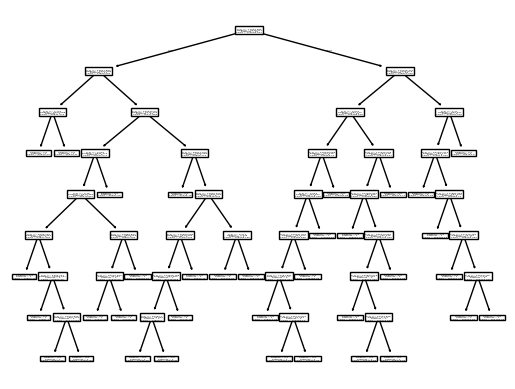

In [84]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plot_tree(regressor)
plt.show()

In [85]:
y_pred = regressor.predict(x_test)

In [86]:
from sklearn.metrics import r2_score
r2_score=r2_score(y_test,y_pred)

In [87]:
r2_score

0.6956464902193537

In [16]:
import pickle

pickle.dump(regressor, open("finalized_model_decision_tree.sav","wb"))